In [19]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

In [20]:
def parse_clipboard_data(text):
    """
    Converts tabular text input (e.g. from copy-pasting) into x and y NumPy arrays.
    Assumes tab or space-separated two-column data.
    """
    # Split lines and filter out empty lines
    lines = [line.strip() for line in text.strip().splitlines() if line.strip()]
    # Split each line by whitespace or tab
    data = [list(map(float, line.split())) for line in lines]
    arr = np.array(data)
    x = arr[:, 0]
    y = arr[:, 1]
    return x, y

In [21]:
def single_gaussian(x,params):
    (c1, mu1, sigma1, b) = params
    res =   b + c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) 
    return res

def double_gaussian(x, params):
    (c1, mu1, sigma1, c2, mu2, sigma2,b) = params
    res =  b + c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) \
          + c2 * np.exp( - (x - mu2)**2.0 / (2.0 * sigma2**2.0) )
    return res

def single_gaussian_fit(params,x,y):
    fit = single_gaussian(x, params)
    return (fit - y)

def double_gaussian_fit(params, x, y):
    fit = double_gaussian(x, params)
    return (fit - y)

def triple_gaussian(x, params):
    (c1, mu1, sigma1, c2, mu2, sigma2, c3, mu3, sigma3, b) = params
    return (
        b 
        + c1 * np.exp(-((x - mu1) ** 2.0) / (2.0 * sigma1 ** 2.0))
        + c2 * np.exp(-((x - mu2) ** 2.0) / (2.0 * sigma2 ** 2.0))
        + c3 * np.exp(-((x - mu3) ** 2.0) / (2.0 * sigma3 ** 2.0))
    )

def triple_gaussian_fit(params, x, y):
    fit = triple_gaussian(x, params)
    return fit - y


#### lorentzians ####

def single_lorentzian(x, params):
    (c1, mu1, gamma1, b) = params
    res = b + c1 * (gamma1**2.0 / ((x - mu1)**2.0 + gamma1**2.0))
    return res

def single_lorentzian_fit(params, x, y):
    fit = single_lorentzian(x, params)
    return (fit - y)

def double_lorentzian(x, params):
    (c1, mu1, gamma1, c2, mu2, gamma2, b) = params
    return (
        b + c1 * (gamma1 ** 2.0 / ((x - mu1) ** 2.0 + gamma1 ** 2.0))
        + c2 * (gamma2 ** 2.0 / ((x - mu2) ** 2.0 + gamma2 ** 2.0))
    )

def double_lorentzian_fit(params, x, y):
    fit = double_lorentzian(x, params)
    return fit - y


def triple_lorentzian(x, params):
    (c1, mu1, gamma1, c2, mu2, gamma2, c3, mu3, gamma3, b) = params
    return (
        b + c1 * (gamma1 ** 2.0 / ((x - mu1) ** 2.0 + gamma1 ** 2.0))
        + c2 * (gamma2 ** 2.0 / ((x - mu2) ** 2.0 + gamma2 ** 2.0))
        + c3 * (gamma3 ** 2.0 / ((x - mu3) ** 2.0 + gamma3 ** 2.0))
    )

def triple_lorentzian_fit(params, x, y):
    fit = triple_lorentzian(x, params)
    return fit - y

In [22]:
raw_data = """
0	-0.21734
1	-0.21726
2	-0.21696
3	-0.21461
4	-0.19221
5	-0.05426
6	0.1945
7	0.6845
8	0.85142
9	0.60594
10	0.77221
11	1.0832
12	0.96629
13	0.48078
14	-0.07986
15	-0.20995
16	-0.21655
17	-0.21717
18	-0.21725
19	-0.21731



"""

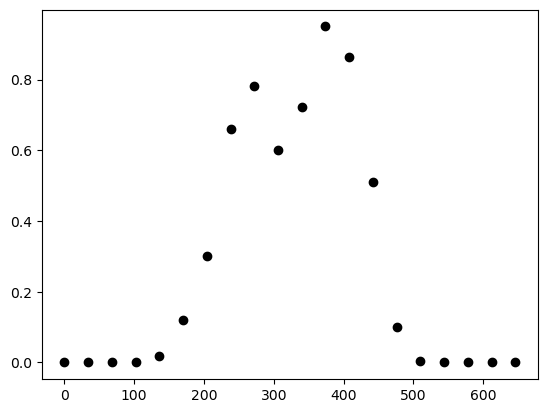

In [23]:
x,y = parse_clipboard_data(raw_data)

pxSize=34 # Pixel size in nm
x = x * pxSize  # Convert x to nm

y=(y-np.min(y))/(np.max(y)-np.min(y))  # Normalize y
y= y * 0.95

plt.figure()
plt.plot(x, y, 'ko')
plt.show()


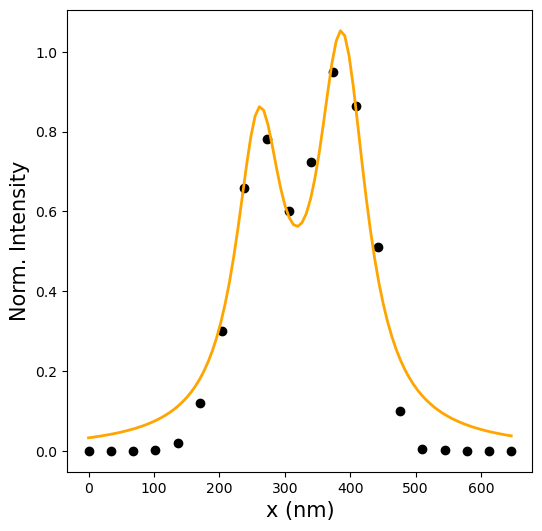

FWHM1: 86.66
FWHM2: 90.45
Peak1-2 distance: 126.91


In [24]:
fit_choice = "lorentz"

x2 = np.linspace(min(x),max(x),100)

params = [
    0.95,250,60,
    0.95,400,60,
    0.1
]

# Least squares fit. 
fit_gauss = leastsq(double_gaussian_fit, params, args=(x, y))
fit_lorentz = leastsq(double_gaussian_fit, params, args=(x, y))

if fit_choice == "gauss":
    fit = fit_gauss
    fwhm_factor = 2.35
else:
    fit = fit_lorentz
    fwhm_factor = 2

# Extract parameters
params1 = fit[0][:3]
params2 = fit[0][:6]
# params3 = fit[0][:9]
bckg = fit[0][-1]

# Calculate FWHM for each Gaussian
fwhm1 = fwhm_factor * params1[2]
fwhm2 = fwhm_factor * params2[2]
# fwhm3 = fwhm_factor * params3[2]

fig = plt.figure(figsize=(6, 6))

# Plot data and fit
if fit_choice == "gauss":
    func = double_gaussian
else:
    func = double_lorentzian

plt.plot(x, y, 'ko', markersize=6)
plt.plot(x2, func(x2, fit[0]), 'orange', linewidth=2)

# Show plot
labels_fontSize=15
ticks_prms={"labelsize":15, "width":2,"length":8}

plt.xlabel('x (nm)',fontsize=labels_fontSize)
plt.ylabel('Norm. Intensity',fontsize=labels_fontSize)

plt.show()


# plot values
results = fit[0]

# group + sort by center so peak1,2,3 are left->right
peaks = np.array([
    [results[0], results[1], results[2]],
    [results[3], results[4], results[5]],
    # [results[6], results[7], results[8]],
], dtype=float)
peaks = peaks[np.argsort(peaks[:, 1])]

(_, mu1, w1), (_, mu2, w2) = peaks

# FWHM
if fit_choice == "gauss":
    fwhm1, fwhm2 = 2.355 * abs(w1), 2.355 * abs(w2)
else:  # lorentzian
    fwhm1, fwhm2 = 2.0 * abs(w1), 2.0 * abs(w2)
# peak-to-peak distances
d12 = abs(mu2 - mu1)
# d23 = abs(mu3 - mu2)

print(f"FWHM1: {fwhm1:.2f}")
print(f"FWHM2: {fwhm2:.2f}")
# print(f"FWHM3: {fwhm3:.2f}")
print(f"Peak1-2 distance: {d12:.2f}")
# print(f"Peak2-3 distance: {d23:.2f}")
